# setup device

In [180]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

# setup Dataset

In [181]:
from torch.utils.data import Dataset
import os
import random
from PIL import Image


class TripletLossDataset(Dataset):
    def __init__(self, split='train', transform=None, max_samples=None, allowed_classes=None,
                 max_samples_per_class=None):
        """
        returns: anc_img, pos_img, neg_img, anc_class, neg_class
        :param split:
        :param transform:
        :param max_samples:
        :param allowed_classes:
        :param max_samples_per_class:
        """

        assert split in ["train", "test", "val"], "split must be 'train' or 'test' or 'val'"

        label_files = {
            'train': 'data/RVL_CDIP/labels/train.txt',
            'test': 'data/RVL_CDIP/labels/test.txt',
            "val": "data/RVL_CDIP/labels/val.txt"
        }

        root_dir = "data/RVL_CDIP/images"
        label_file = label_files[split]

        self.label_to_images = {}
        self.image_to_label = {}
        self.all_images = []

        self.allowed_classes = allowed_classes
        self.class_map = {cls: i for i, cls in enumerate(allowed_classes)} if allowed_classes else None

        with open(label_file, 'r') as f:
            for line in f:

                path, label = line.strip().split()
                full_path = os.path.join(root_dir, path)
                label = int(label)

                if allowed_classes is not None and label not in allowed_classes:
                    continue

                if label not in self.label_to_images:
                    self.label_to_images[label] = []

                if max_samples_per_class is not None and len(self.label_to_images[label]) >= max_samples_per_class:
                    continue

                if max_samples is not None and len(self) >= max_samples:
                    break

                self.label_to_images[label].append(full_path)
                self.image_to_label[full_path] = label
                self.all_images.append((full_path, label))

        self.labels = list(self.label_to_images.keys())
        self.transform = transform

    def num_classes(self):
        return len(self.label_to_images.keys())

    def __len__(self):
        return len(self.all_images)

    def __getitem__(self, idx):
        anc_path, anc_class = self.all_images[idx]

        pos_path = random.choice([
            path for path in self.label_to_images[anc_class] if path != anc_path
        ])
        neg_class = random.choice([l for l in self.labels if l != anc_class])
        neg_path = random.choice(self.label_to_images[neg_class])

        anc_img = Image.open(anc_path)
        pos_img = Image.open(pos_path)
        neg_img = Image.open(neg_path)

        if self.transform:
            anc_img = self.transform(anc_img)
            pos_img = self.transform(pos_img)
            neg_img = self.transform(neg_img)

        if self.class_map:
            anc_class = self.class_map[anc_class]  # z.B. 2 → 0, 6 → 1
            neg_class = self.class_map[neg_class]

        return anc_img, pos_img, neg_img, anc_class, neg_class

# setup Hyperparams

In [182]:
from itertools import product

template_count_variations = [
    1, 2, 5
]

template_strategy_variations = [
    "RANDOM", "DISTANT"
]

allowed_class_variations = [
    [4, 8],
    [4, 7, 8, 12],
    [1, 2, 4, 7, 8, 11, 12, 14],
]

new_allowed_class_variations = [
    [4, 8, 12],
    [4, 7, 8, 12, 14],
    [1, 2, 4, 7, 8, 10, 11, 12, 14],
]

combinations = []

for count, strategy in product(template_count_variations, template_strategy_variations):
    for idx, (classic, new) in enumerate(zip(allowed_class_variations, new_allowed_class_variations), start=1):
        combo = {
            "template_count": count,
            "template_strategy": strategy,
            "allowed_classes": classic,
            "new_allowed_classes": new,
            "variation_index": idx
        }
        combinations.append(combo)

# for combo in combinations:
#     print(f"--- Variation {combo['variation_index']} ---")
#     print(f"Template Count     : {combo['template_count']}")
#     print(f"Template Strategy  : {combo['template_strategy']}")
#     print(f"Allowed Classes    : {combo['allowed_classes']}")
#     print(f"New Allowed Classes: {combo['new_allowed_classes']}")
#     print()

ALLOWED_CLASSES = allowed_class_variations[0]
NEW_ALLOWED_CLASSES = new_allowed_class_variations[0]
TEMPLATE_COUNT = template_count_variations[1]
TEMPLATE_STRATEGY = template_strategy_variations[0]

print(ALLOWED_CLASSES)
print(NEW_ALLOWED_CLASSES)
print(TEMPLATE_COUNT)
print(TEMPLATE_STRATEGY)

[4, 8]
[4, 8, 12]
2
RANDOM


In [183]:
from torch.utils.data import DataLoader
from torchvision import transforms

IMAGE_SIZE = (224, 224)

# Define a basic transform
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),  # resize to a standard size
    transforms.ToTensor()  # convert to tensor
])

original_dataset_length = 0
with open("data/RVL_CDIP/labels/train.txt", "r") as f:
    original_dataset_length = sum(1 for _ in f)
print(original_dataset_length)

MAX_SAMPLES = original_dataset_length / 4

BATCH_SIZE = 32

320000


In [184]:
# Create the dataset instance
train_dataset = TripletLossDataset(split='train', transform=transform, max_samples=MAX_SAMPLES,
                                   allowed_classes=ALLOWED_CLASSES)
train_dataloader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataset = TripletLossDataset(split="test", transform=transform, max_samples=1000,
                                  allowed_classes=ALLOWED_CLASSES)
test_dataloader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## class names

In [185]:
class_names = {
    0: "letter",
    1: "form",
    2: "email",
    3: "handwritten",
    4: "advertisement",
    5: "scientific report",
    6: "scientific publication",
    7: "specification",
    8: "file folder",
    9: "news article",
    10: "budget",
    11: "invoice",
    12: "presentation",
    13: "questionnaire",
    14: "resume",
    15: "memo"
}

### printing an plotting example batch

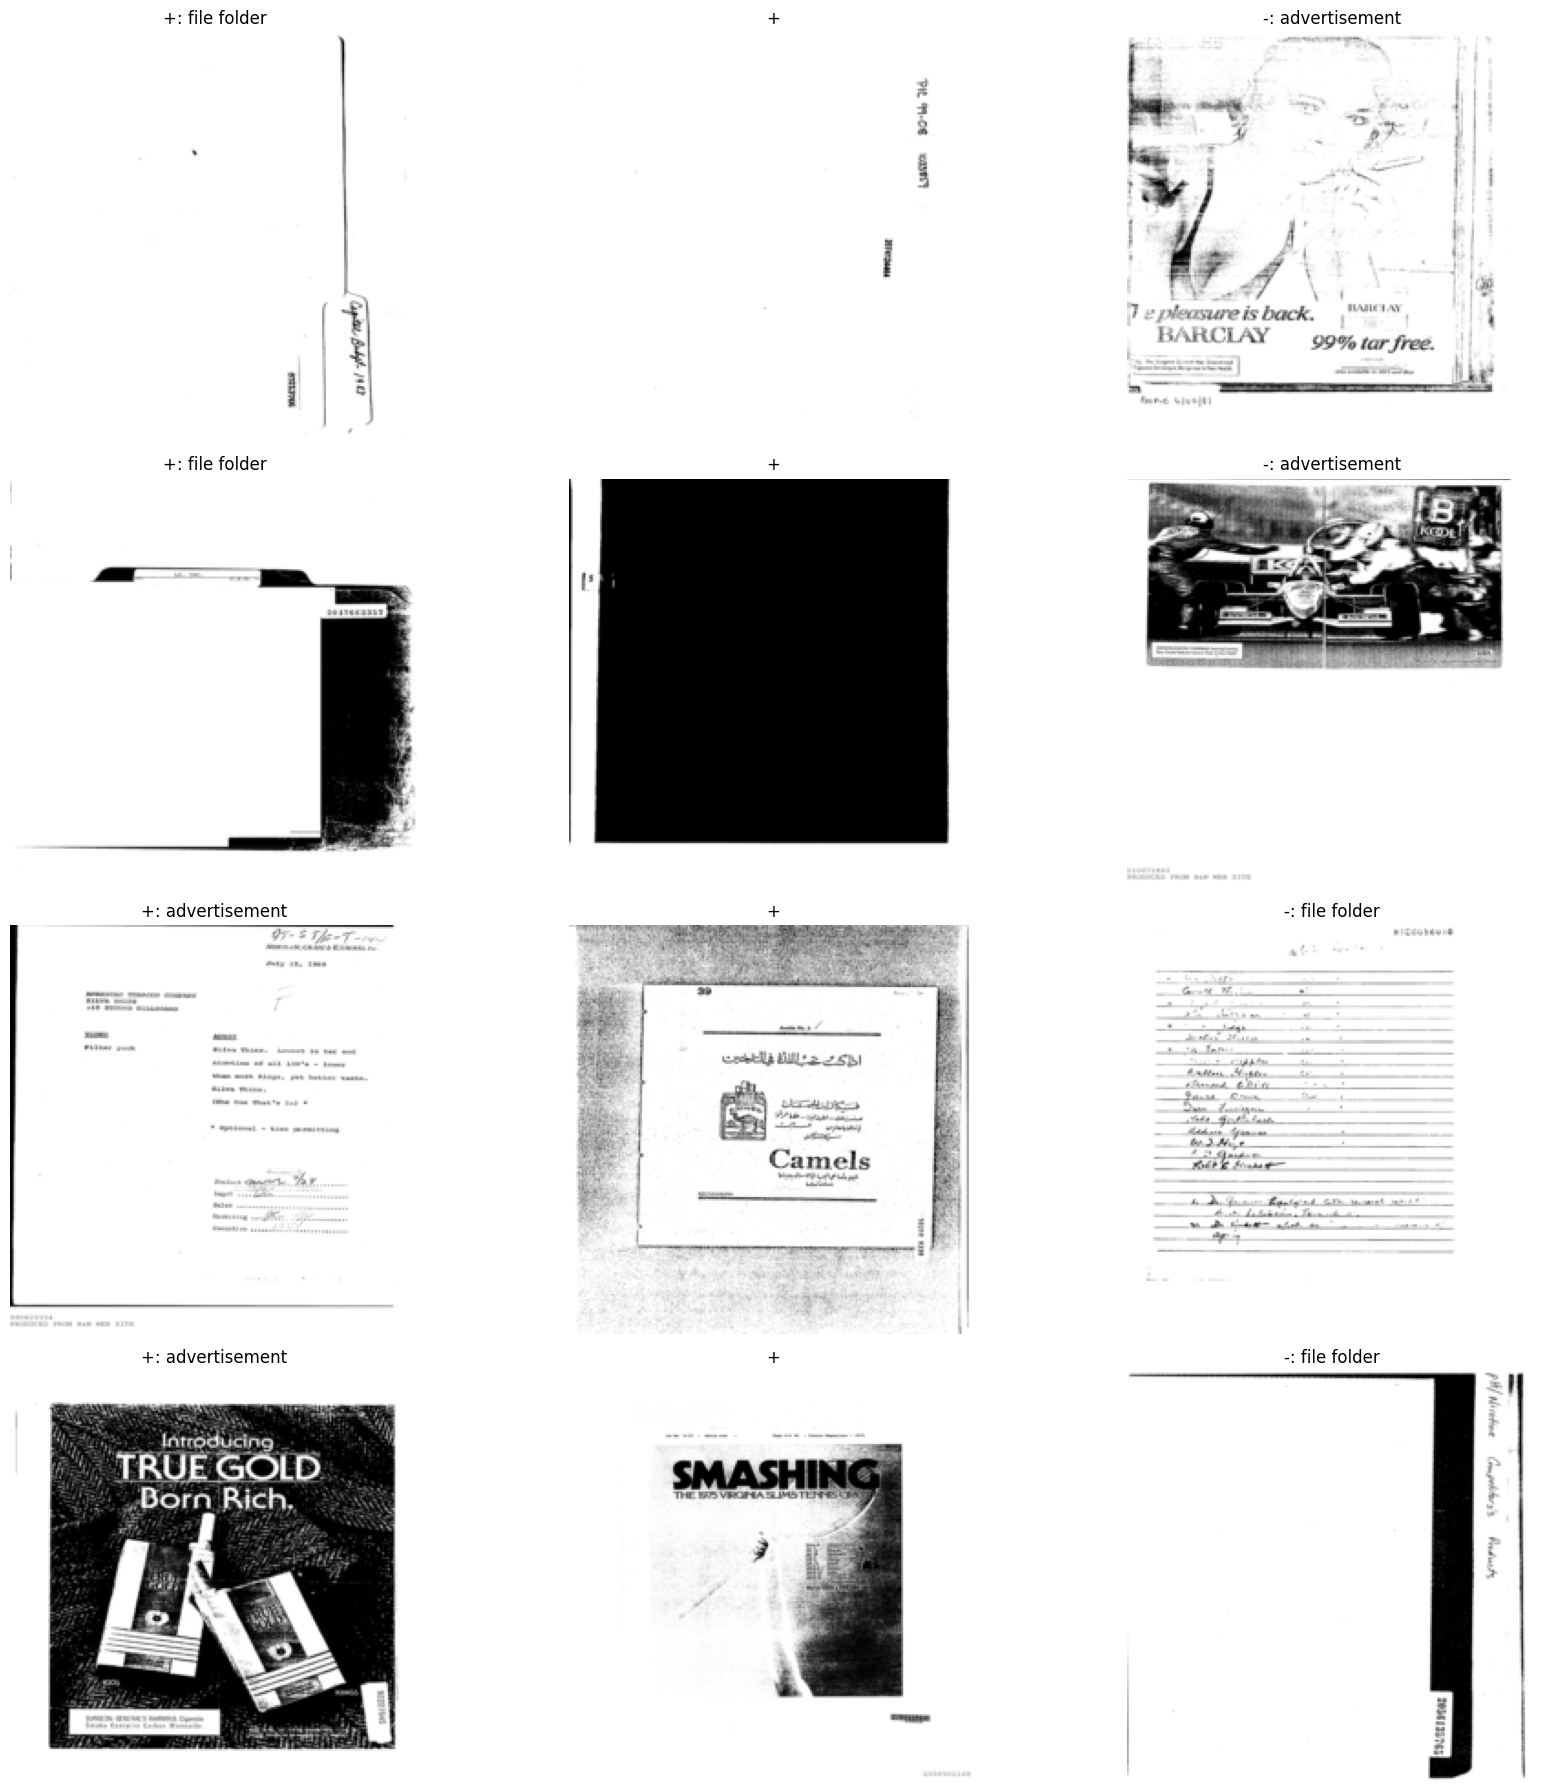

In [186]:
import matplotlib.pyplot as plt

sample_batch = next(iter(train_dataloader))
anchor_batch, positive_batch, negative_batch, anchor_class, negative_class = sample_batch

# Plot the 8 triplets
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 18))

for i in range(4):
    anchor = anchor_batch[i].squeeze()
    positive = positive_batch[i].squeeze()
    negative = negative_batch[i].squeeze()

    # Falls es noch Tensoren sind, konvertieren
    if hasattr(anchor, "numpy"):
        anchor = anchor.cpu().numpy()
        positive = positive.cpu().numpy()
        negative = negative.cpu().numpy()

    # Hole die gemappten Klassen und Labels
    anchor_label_idx = ALLOWED_CLASSES[anchor_class[i].item()]
    anchor_label = class_names[anchor_label_idx]

    negative_label_idx = ALLOWED_CLASSES[negative_class[i].item()]
    negative_label = class_names[negative_label_idx]

    # Anchor image
    axes[i, 0].imshow(anchor, cmap='gray')
    axes[i, 0].set_title(f"+: {anchor_label}")
    axes[i, 0].axis('off')

    # Positive image (kein Mapping nötig)
    axes[i, 1].imshow(positive, cmap='gray')
    axes[i, 1].set_title("+")
    axes[i, 1].axis('off')

    # Negative image
    axes[i, 2].imshow(negative, cmap='gray')
    axes[i, 2].set_title(f"-: {negative_label}")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()


# setup Model

In [187]:
import torch
from torch import nn
from torchvision import models


class ResNet18Model(nn.Module):
    def __init__(self, input_shape: int, output_shape: int):
        super().__init__()
        self.model = models.resnet18()

        if input_shape == 1:
            self.model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        num_ftrs = self.model.fc.in_features
        self.model.fc = nn.Linear(num_ftrs, output_shape)

    def forward(self, x):
        return self.model(x)


# triplet loss

In [188]:
import torch.nn.functional as F


def triplet_loss_hard_mining(anchor_batch, positive_batch, negative_batch, margin=1.0):
    # Berechne Distanzen für jedes Triplet im Batch (1:1)
    d_ap = F.pairwise_distance(anchor_batch, positive_batch, p=2)
    d_an = F.pairwise_distance(anchor_batch, negative_batch, p=2)

    # Bestimme härteste Triplets: wo d_ap am größten und d_an am kleinsten ist
    k = max(1, anchor_batch.size(0) // 2)

    # Hard positives: größte d_ap
    # _, hardest_pos_idx = torch.topk(d_ap, k=k, largest=True)
    # Hard negatives: kleinste d_an
    _, hardest_neg_idx = torch.topk(d_an, k=k, largest=False)

    # Wähle die Distanzen entsprechend
    # hard_pos_dists = d_ap[hardest_pos_idx]
    hard_neg_dists = d_an[hardest_neg_idx]

    # Optional: mische zusätzliche zufällige Triplets für Robustheit
    rand_indices = torch.randperm(d_ap.size(0))[:k]
    rand_pos_dists = d_ap[rand_indices]
    # rand_neg_dists = d_an[rand_indices]
    # all_pos = torch.cat([hard_pos_dists, rand_pos_dists], dim=0)
    # all_neg = torch.cat([hard_neg_dists, rand_neg_dists], dim=0)

    # Berechne den finalen Loss
    loss = F.relu(rand_pos_dists - hard_neg_dists + margin)
    return loss.mean()


def triplet_loss(anchor_batch, positive_batch, negative_batch, margin=1.0):
    # Berechne L2-Distanzen zwischen korrespondierenden Triplets
    d_ap = F.pairwise_distance(anchor_batch, positive_batch, p=2)
    d_an = F.pairwise_distance(anchor_batch, negative_batch, p=2)

    # Standard Triplet Loss
    loss = F.relu(d_ap - d_an + margin)
    return loss.mean()


class TripletLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative, hard=False):
        if hard:
            return triplet_loss_hard_mining(anchor, positive, negative, margin=self.margin)
        else:
            return triplet_loss(anchor, positive, negative, margin=self.margin)


# instantiate model etc

In [189]:
print(f"using {device}")
MARGIN = 0.3
net = ResNet18Model(input_shape=1, output_shape=128).to(device)
criterion = TripletLoss(margin=MARGIN).to(device)
optimizer = torch.optim.AdamW(net.parameters(), lr=3e-4, weight_decay=1e-4)

using cuda


### helper func

In [190]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

# test step

In [191]:
def test_step(model: nn.Module,
              dataloader: torch.utils.data.DataLoader,
              criterion: nn.Module):
    test_loss = 0.0
    model.eval()
    dataloader_progress = tqdm(dataloader, desc="Testing...", colour="gray")

    with torch.inference_mode():
        for i, (a, p, n, *_) in enumerate(dataloader_progress):
            a, p, n = a.to(device), p.to(device), n.to(device)

            a = model(a)
            p = model(p)
            n = model(n)
            a, p, n = F.normalize(a, p=2, dim=1), F.normalize(p, p=2, dim=1), F.normalize(n, p=2, dim=1)
            loss = criterion(a, p, n, False)  # while testing we want average values, so no hard mining

            if i <= 1:
                avg_distance_ap = F.pairwise_distance(a, p).mean()
                avg_distance_an = F.pairwise_distance(a, n).mean()
                print(
                    f"avg distance anchor positive: {avg_distance_ap}\navg distance anchor negative: {avg_distance_an}\n")

            test_loss += loss.item()
            avg_test_loss = test_loss / (i + 1)
            dataloader_progress.set_postfix(avg_loss=avg_test_loss)

    return avg_test_loss


# train step

In [192]:
from tqdm.auto import tqdm
import matplotlib.pyplot as plt


def train_step(model: nn.Module,
               dataloader: torch.utils.data.DataLoader,
               criterion: nn.Module,
               optimizer: torch.optim.Optimizer,
               hard_mining=False,
               test_dataloader=None):
    train_loss = 0.0
    avg_loss = 0.0
    loss_per_batch = []
    model.train()

    dataloader_progress = tqdm(dataloader, desc="Training...")
    for i, (a, p, n, *_) in enumerate(dataloader_progress):
        a, p, n = a.to(device), p.to(device), n.to(device)

        a = model(a)
        p = model(p)
        n = model(n)
        a, p, n = F.normalize(a, p=2, dim=1), F.normalize(p, p=2, dim=1), F.normalize(n, p=2, dim=1)

        if hard_mining and i % 2 == 0:
            h = True
        else:
            h = False
        loss = criterion(a, p, n, h)
        loss_per_batch.append(loss.item())

        optimizer.zero_grad()
        loss.backward()

        optimizer.step()

        train_loss += loss.item()
        avg_loss = train_loss / (i + 1)
        dataloader_progress.set_postfix(avg_loss=avg_loss)

        # if i % 100 == 0:
        #     print("d(a,p):", torch.norm(a - p, dim=1).mean().item())
        #     print("d(a,n):", torch.norm(a - n, dim=1).mean().item())

        if i % 200 == 0 and i > 0 and test_dataloader is not None and avg_loss <= MARGIN:
            test_step(model, test_dataloader, criterion)

    plt.figure(figsize=(10, 4))
    plt.plot(loss_per_batch, label='Batch Loss')
    plt.xlabel("Batch Index")
    plt.ylabel("Loss")
    plt.title("Loss pro Batch während Training")
    plt.grid(True)
    plt.legend()
    plt.show()

    return avg_loss

# try to load model

In [193]:
from pathlib import Path

MODEL_PATH = Path("models/triplet")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

skip_training = False
should_try_to_load_model = True  # True always skips training, False makes overwriting old training data possible

model_name_map = {
    2: "triplet_model_2.pth",
    4: "triplet_model_4.pth",
    8: "triplet_model_8.pth",
}
MODEL_NAME = model_name_map.get(len(ALLOWED_CLASSES), "unnamed_model.pth")
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

if MODEL_SAVE_PATH.exists() and should_try_to_load_model:
    print(f"loaded model: {MODEL_SAVE_PATH}, skipping training")
    net.load_state_dict(torch.load(MODEL_SAVE_PATH, weights_only=True))
    skip_training = True
else:
    if should_try_to_load_model:
        print(f"{MODEL_SAVE_PATH} does not exist, continuing to training")
    else:
        print("loading a model was not desired, continuing to training")
    skip_training = False

loaded model: models\triplet\triplet_model_2.pth, skipping training


### helper func

In [194]:
# helper func
def format_time(seconds):
    minutes = int(seconds // 60)
    seconds = int(seconds % 60)
    return f"{minutes}m {seconds}s"

# visual evaluation

In [195]:
import torch.nn.functional as F
import matplotlib.pyplot as plt


def visualize_triplet_distances(model, dataloader, device, allowed_classes, max_triplets=8):
    """
    Visualizes Euclidean distances between anchor-positive and anchor-negative pairs in a triplet setting.
    Highlights whether the triplet loss condition is satisfied.
    """
    model.eval()

    with torch.inference_mode():
        for anchors, positives, negatives, anchor_class_labels, negative_class_labels in dataloader:
            anchors, positives, negatives = anchors.to(device), positives.to(device), negatives.to(device)

            # Get embeddings
            emb_a = model(anchors)
            emb_p = model(positives)
            emb_n = model(negatives)
            emb_a, emb_p, emb_n = F.normalize(emb_a, p=2, dim=1), F.normalize(emb_p, p=2, dim=1), F.normalize(emb_n,
                                                                                                              p=2,
                                                                                                              dim=1)

            # Compute distances
            dist_ap = F.pairwise_distance(emb_a, emb_p)
            dist_an = F.pairwise_distance(emb_a, emb_n)

            num_triplets = min(max_triplets, len(anchors))
            fig, axes = plt.subplots(num_triplets, 3, figsize=(9, 3 * num_triplets))
            if num_triplets == 1:
                axes = [axes]

            for i in range(num_triplets):
                a_img = anchors[i].cpu().squeeze()
                p_img = positives[i].cpu().squeeze()
                n_img = negatives[i].cpu().squeeze()

                ap_dist = dist_ap[i].item()
                an_dist = dist_an[i].item()

                a_class_name = class_names[allowed_classes[anchor_class_labels[i]]]
                n_class_name = class_names[allowed_classes[negative_class_labels[i]]]

                # Check triplet condition
                satisfied = ap_dist < an_dist
                color = 'green' if satisfied else 'red'

                # Anchor
                axes[i][0].imshow(a_img, cmap='gray')
                axes[i][0].set_title(f"Anchor: {a_class_name}", color='black')
                axes[i][0].axis('off')

                # Positive
                axes[i][1].imshow(p_img, cmap='gray')
                axes[i][1].set_title(f"Positive (same): {a_class_name}\nDist: {ap_dist:.2f}", color=color)
                axes[i][1].axis('off')

                # Negative
                axes[i][2].imshow(n_img, cmap='gray')
                axes[i][2].set_title(f"Negative: {n_class_name}\nDist: {an_dist:.2f}", color=color)
                axes[i][2].axis('off')

            plt.tight_layout()
            plt.show()
            break  # Remove to visualize more batches


# training

In [196]:
from tqdm.auto import tqdm
from timeit import default_timer as timer
import matplotlib.pyplot as plt

# Training loop with tqdm progress bar
num_epochs = 3

if not skip_training:
    for epoch in range(num_epochs):
        start = timer()

        if epoch >= 1:
            hard_mining = True
        else:
            hard_mining = False

        print(f"Epoch {epoch + 1}/{num_epochs}: Training...")
        avg_train_loss = train_step(net, train_dataloader, criterion, optimizer, hard_mining, test_dataloader)

        # print(f"Epoch {epoch + 1}/{num_epochs}: Testing...")
        # avg_test_loss = test_step(net, test_dataloader, criterion)
        # test_losses.append(avg_test_loss)

        total_epoch_elapsed = timer() - start
        remaining_time = total_epoch_elapsed * (num_epochs - epoch - 1)
        print(
            f"Epoch duration: {format_time(total_epoch_elapsed)}. "
            f"Estimated remaining time: {format_time(remaining_time)}."
        )

        val_dataset = TripletLossDataset(split="val", transform=transform, max_samples=5000,
                                         allowed_classes=ALLOWED_CLASSES)
        val_dataloader = DataLoader(dataset=val_dataset, shuffle=False, batch_size=8)
        visualize_triplet_distances(net, val_dataloader, device, allowed_classes=ALLOWED_CLASSES, max_triplets=8)
else:
    print(f"loaded a model, skipping training")

loaded a model, skipping training


## saving the model after training

In [197]:
# falls trainiert wurde, speichern, sonst nichts tun
if not skip_training:
    print(f"saving model: {MODEL_SAVE_PATH}")
    torch.save(obj=net.state_dict(), f=MODEL_SAVE_PATH)

## initializing eval 

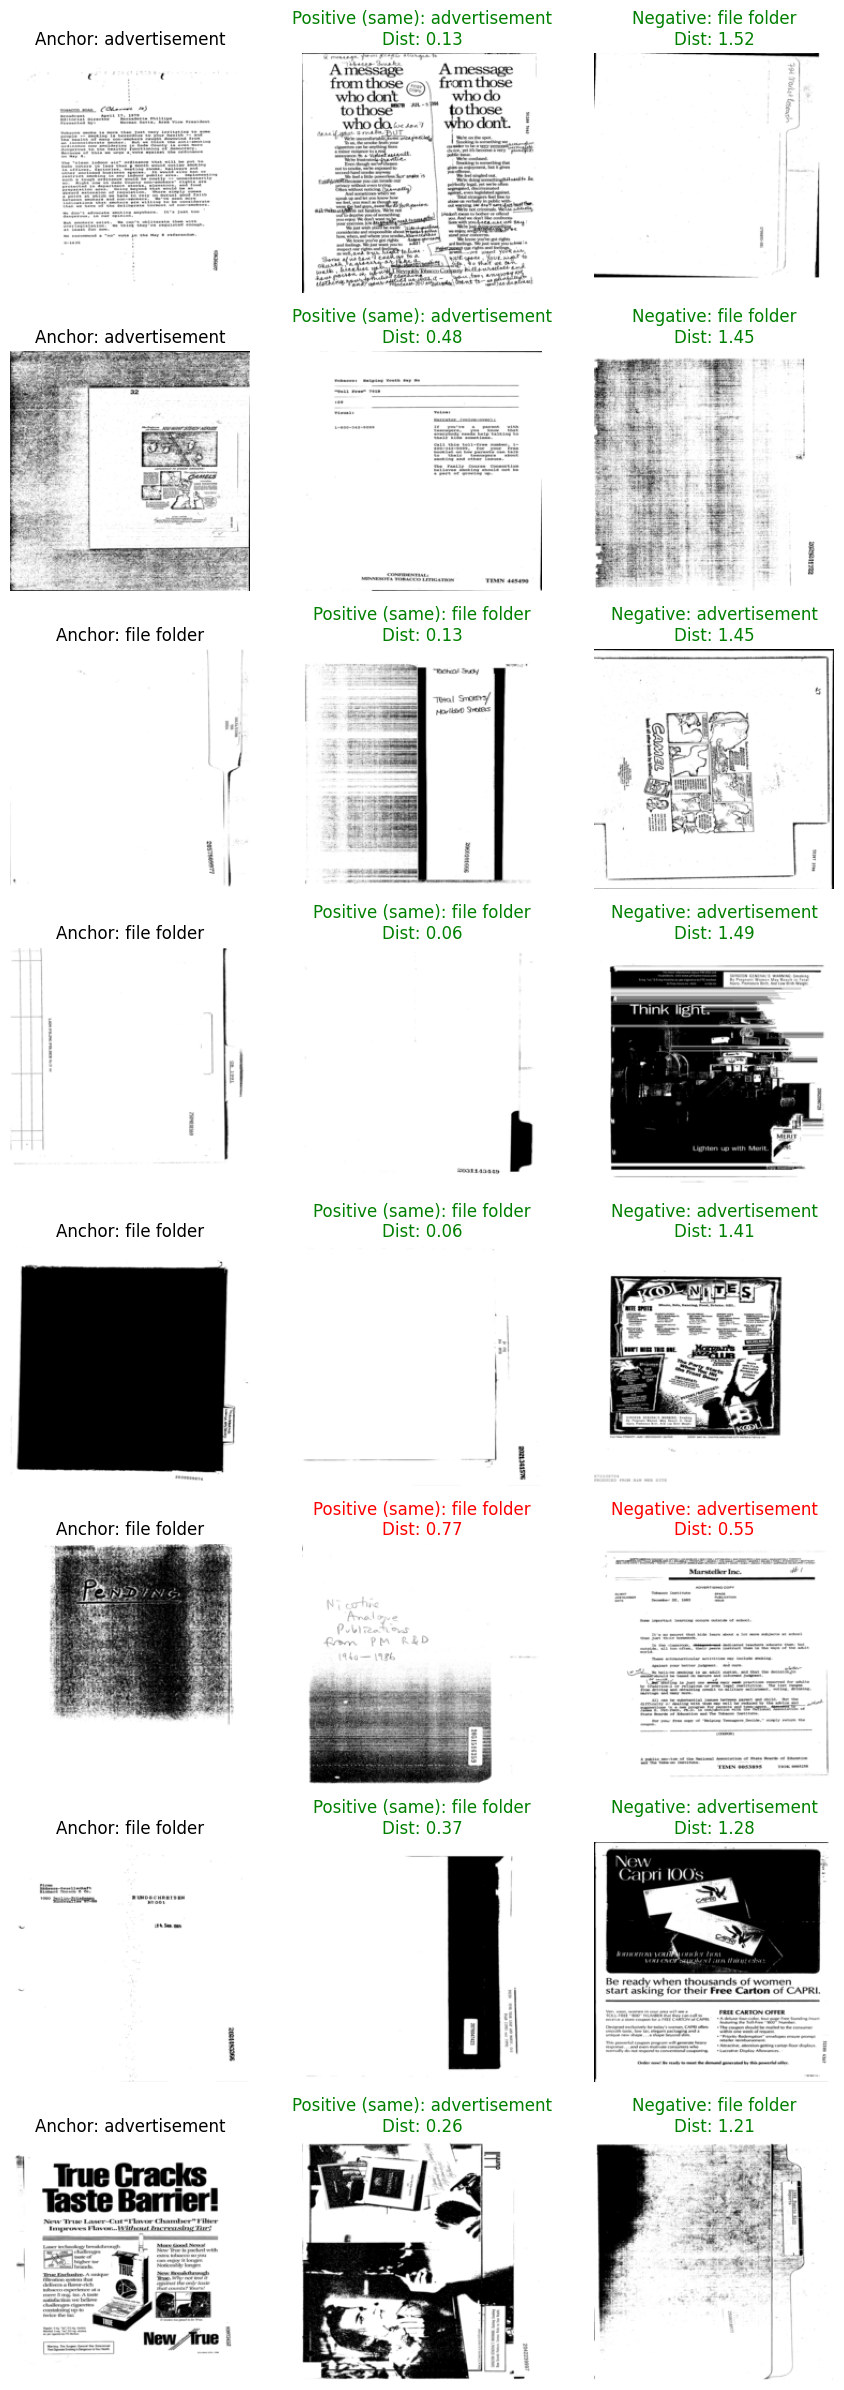

In [198]:
val_dataset = TripletLossDataset(split="val", transform=transform, max_samples=5000,
                                 allowed_classes=ALLOWED_CLASSES)
val_dataloader = DataLoader(dataset=val_dataset, shuffle=False, batch_size=8)
visualize_triplet_distances(net, val_dataloader, device, allowed_classes=ALLOWED_CLASSES, max_triplets=8)

# compute average distance

In [199]:
import torch
import torch.nn.functional as F
import numpy as np


def compute_average_distance(model, dataloader, device, max_batches=None):
    model.eval()
    all_dists = []

    with torch.inference_mode():
        for i, (a, p, n, *_) in enumerate(dataloader):
            a, p, n = a.to(device), p.to(device), n.to(device)
            a = F.normalize(model(a), p=2, dim=1)
            p = F.normalize(model(p), p=2, dim=1)
            n = F.normalize(model(n), p=2, dim=1)

            pos_dist = F.pairwise_distance(a, p).cpu()
            neg_dist = F.pairwise_distance(a, n).cpu()

            all_dists.extend(pos_dist.cpu().numpy())
            all_dists.extend(neg_dist.cpu().numpy())

            if max_batches is not None and i + 1 >= max_batches:
                break

    avg_distance = np.mean(all_dists)
    print(f"Average distance (all pairs): {avg_distance:.3f}")
    return avg_distance

# distance histogram

In [200]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np


def plot_distance_histogram(model, dataloader, device, max_batches=None, bins=50, threshold=1.0):
    model.eval()
    same_dists = []
    diff_dists = []

    correct_pos = 0
    correct_neg = 0

    with torch.inference_mode():
        for i, (a, p, n, *_) in enumerate(dataloader):
            a, p, n = a.to(device), p.to(device), n.to(device)

            a = F.normalize(model(a), p=2, dim=1)
            p = F.normalize(model(p), p=2, dim=1)
            n = F.normalize(model(n), p=2, dim=1)

            pos_dist = F.pairwise_distance(a, p).cpu()
            neg_dist = F.pairwise_distance(a, n).cpu()
            # print(f"pos dist: {pos_dist}")
            # print(f"neg dist: {neg_dist}")

            for dist in pos_dist:
                # print(dist)
                if dist <= threshold:
                    correct_pos += 1
                same_dists.append(dist)
            for dist in neg_dist:
                if dist >= threshold:
                    correct_neg += 1
                diff_dists.append(dist)

            if max_batches is not None and i + 1 >= max_batches:
                break

    # Plot histogram
    plt.figure(figsize=(10, 6))
    plt.hist(same_dists, bins=bins, alpha=0.6, label='Same Class', color='green')
    plt.hist(diff_dists, bins=bins, alpha=0.6, label='Different Class', color='red')
    plt.axvline(x=threshold, color='blue', linestyle='--', label=f'Threshold = {threshold:.5f}')
    plt.xlabel("Euclidean Distance")
    plt.ylabel("Number of Pairs")
    plt.title("Distribution of Pairwise Distances")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Accuracy
    same_accuracy = correct_pos / len(same_dists)
    diff_accuracy = correct_neg / len(diff_dists)
    overall_accuracy = (correct_pos + correct_neg) / (len(same_dists) + len(diff_dists))

    print(f"Avg distance (same): {np.mean(same_dists):.3f}")
    print(f"Avg distance (diff): {np.mean(diff_dists):.3f}")
    print(f"Accuracy (same class): {same_accuracy * 100:.2f}%")
    print(f"Accuracy (different class): {diff_accuracy * 100:.2f}%")
    print(f"Overall accuracy: {overall_accuracy * 100:.2f}%")

Average distance (all pairs): 0.777


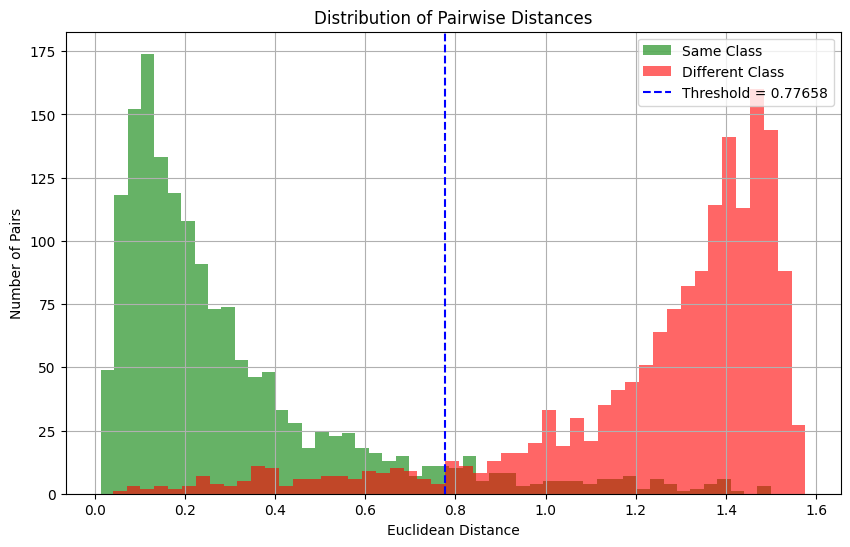

Avg distance (same): 0.300
Avg distance (diff): 1.254
Accuracy (same class): 92.25%
Accuracy (different class): 91.56%
Overall accuracy: 91.91%


In [201]:
thres = compute_average_distance(net, val_dataloader, device, 200)
# print(thres)
plot_distance_histogram(net, val_dataloader, device, max_batches=200, threshold=thres)

# Class Template Dataset

In [202]:
from torch.utils.data import Dataset
import os
import random
from PIL import Image


class ClassTemplateDataset(Dataset):
    def __init__(self, cls: int, max_samples_per_class=1, transform=None, strategy=None, search_count=2000):

        assert strategy in [None, "RANDOM", "DISTANT"], "strategy must be RANDOM or DISTANT"

        root_dir = "data/RVL_CDIP/images"
        label_file = "data/RVL_CDIP/labels/val.txt"

        self.all_image_paths = []
        self.cls = cls
        self.transform = transform

        with open(label_file, 'r') as f:
            for line in f:
                path, label = line.strip().split()
                full_path = os.path.join(root_dir, path)
                label = int(label)

                if label != cls:
                    continue

                if len(self.all_image_paths) >= max_samples_per_class:
                    break

                if len(self.all_image_paths) >= 1 and strategy == "DISTANT":
                    current_imgs = [Image.open(path) for path, _ in self.all_image_paths]
                    current_imgs = [self.transform(img).to(device) for img in current_imgs]
                    current_imgs = [img.unsqueeze(0) for img in current_imgs]

                    highest_dist = 0
                    final_choice = None
                    for i, line in enumerate(f):
                        if search_count is not None and i >= search_count and final_choice is not None:
                            break
                        path, label = line.strip().split()
                        full_path = os.path.join(root_dir, path)
                        label = int(label)
                        if label != cls:
                            continue
                        new_img = Image.open(full_path)
                        new_img = self.transform(new_img).to(device)
                        new_img = new_img.unsqueeze(0)

                        avg_dist = 0
                        for img in current_imgs:
                            emb1 = net(img)
                            emb2 = net(new_img)
                            avg_dist += F.pairwise_distance(emb1, emb2)
                        avg_dist /= len(current_imgs)

                        if avg_dist > highest_dist:
                            highest_dist = avg_dist
                            final_choice = full_path
                    self.all_image_paths.append((final_choice, label))
                else:
                    self.all_image_paths.append((full_path, label))

    def get_class(self):
        return self.cls

    def __len__(self):
        return len(self.all_image_paths)

    def __getitem__(self, idx):
        img_path, img_class = self.all_image_paths[idx]
        img = Image.open(img_path)

        if self.transform:
            img = self.transform(img)

        img_class = 0
        return img, img_class

    def get_all_items(self):
        imgs = []
        for img_path, _ in self.all_image_paths:
            img = Image.open(img_path)

            if self.transform:
                img = self.transform(img)  # PIL -> Tensor (C,H,W)

            imgs.append(img)

        return imgs

# template sampling strategy/count

In [203]:
print(f"ALLOWED_CLASSES: {ALLOWED_CLASSES}")
print(f"NEW_ALLOWED_CLASSES: {NEW_ALLOWED_CLASSES}")


def create_datasets(list_of_classes, max_templates, transform=None, strategy=None):
    datasets = []
    for cls in list_of_classes:
        datasets.append(
            ClassTemplateDataset(cls, max_samples_per_class=max_templates, transform=transform, strategy=strategy,
                                 search_count=500))
    return datasets


NEW_CLASSES_ONLY = list(set(NEW_ALLOWED_CLASSES) - set(ALLOWED_CLASSES))
print(f"NEW_CLASSES_ONLY: {NEW_CLASSES_ONLY}")

known_class_datasets = create_datasets(ALLOWED_CLASSES, max_templates=TEMPLATE_COUNT, transform=transform,
                                       strategy=TEMPLATE_STRATEGY)

ALLOWED_CLASSES: [4, 8]
NEW_ALLOWED_CLASSES: [4, 8, 12]
NEW_CLASSES_ONLY: [12]


# classification

In [204]:
def predict_class_of_img(model: nn.Module, img, known_class_datasets, threshold=0.5, give_raw_value=False):
    """

    :param model: the model making the predictions
    :param img: image to be predicted on (shape must be [1, 1, 224, 224])
    :param known_class_datasets: list of datasets where the templates live
    :param threshold: threshold defining how confident the model must be to predict a class
    :return: the predicted class (0-15) of the given image, if no prediction could be made confidently it returns -1
    """
    assert img.shape == torch.Size(
        [1, 1, 224, 224]), "image shape must be [1, 1, 224, 224], hint: an unsqueeze(0) could fix it"
    model.eval()

    best_class = None
    best_mean_dist = float("inf")

    with torch.inference_mode():
        for cls_data in known_class_datasets:

            cls_data_dists = []
            for img2 in cls_data.get_all_items():
                img2 = img2.unsqueeze(0)  # Batch dimension für model hinzufügen

                img, img2 = img.to(device), img2.to(device)
                emb1 = F.normalize(model(img), p=2, dim=1)
                emb2 = F.normalize(model(img2), p=2, dim=1)
                dists = F.pairwise_distance(emb1, emb2)

                cls_data_dists.append(dists)
            min_dist = torch.cat(cls_data_dists, dim=0).min().item()
            if min_dist <= best_mean_dist:
                best_mean_dist = min_dist
                best_class = cls_data.get_class()

        if give_raw_value:
            return best_mean_dist

        if best_mean_dist > threshold:
            return -1
        else:
            return best_class


In [205]:
def print_pred(pred):
    if pred == -1:
        print(f"{pred}: unknown")
    else:
        print(f"{pred}: {class_names[pred]}")

## preparing the dataloader for classification

In [206]:
dataset_with_new_classes = TripletLossDataset(
    allowed_classes=NEW_ALLOWED_CLASSES,
    split="val",
    transform=transform,
    max_samples_per_class=200
)
dataloader_with_new_classes = DataLoader(
    dataset=dataset_with_new_classes,
    batch_size=1,
    shuffle=False
)

for label, images in dataset_with_new_classes.label_to_images.items():
    print(f"Label: {label}, Anzahl Bilder: {len(images)}")

Label: 4, Anzahl Bilder: 200
Label: 12, Anzahl Bilder: 200
Label: 8, Anzahl Bilder: 200


## compute average distance of images from known classes

In [207]:
dataset_with_old_classes = TripletLossDataset(allowed_classes=ALLOWED_CLASSES, split="val", transform=transform,
                                              max_samples_per_class=200)
dataloader_with_old_classes = DataLoader(dataset=dataset_with_old_classes, batch_size=1, shuffle=False)

dists = []
net.eval()
with torch.inference_mode():
    for batch in dataloader_with_old_classes:
        a, p, n, a_cls, n_cls = batch
        mapped_a_cls = ALLOWED_CLASSES[a_cls]
        mapped_n_cls = ALLOWED_CLASSES[n_cls]

        dist1 = predict_class_of_img(net, a, known_class_datasets, give_raw_value=True)
        dist2 = predict_class_of_img(net, n, known_class_datasets, give_raw_value=True)
        dists.append(dist1)
        dists.append(dist2)

In [208]:
mean_dist = np.mean(dists)
print(mean_dist)

0.20843932793128717



================= Threshold: 0.1980173615347228 =================


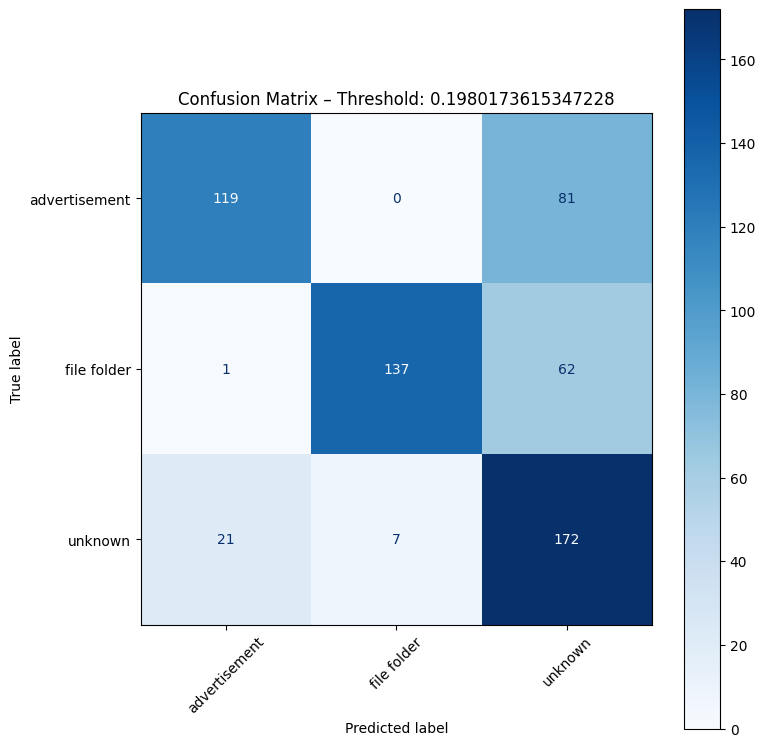

Klasse 'advertisement':
  -> Recall:    59.50%
  -> Precision: 84.40%
Klasse 'file folder':
  -> Recall:    68.50%
  -> Precision: 95.14%
Klasse 'unknown':
  -> Recall:    86.00%
  -> Precision: 54.60%
Gesamt-Accuracy: 71.33%

================= Threshold: 0.20843932793128717 =================


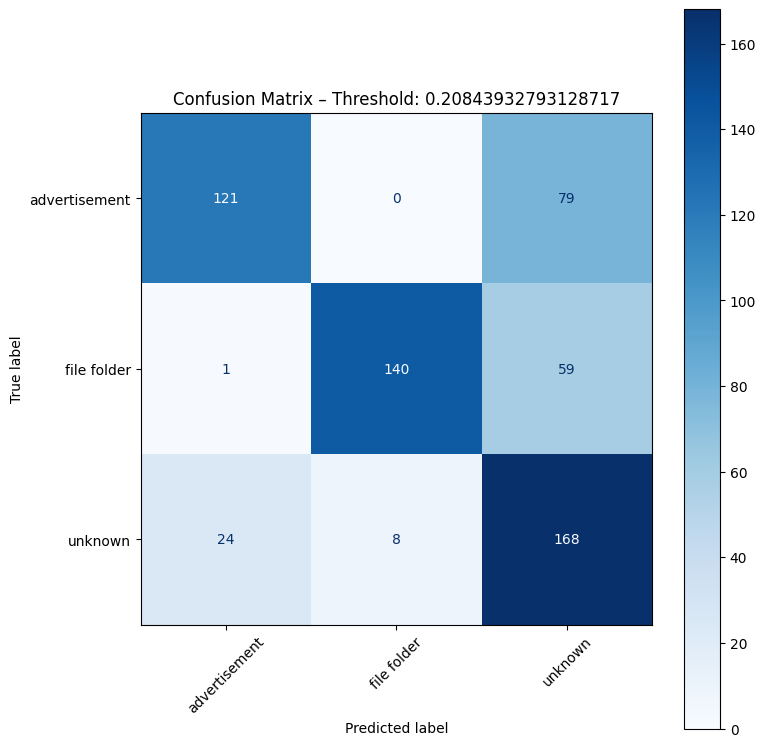

Klasse 'advertisement':
  -> Recall:    60.50%
  -> Precision: 82.88%
Klasse 'file folder':
  -> Recall:    70.00%
  -> Precision: 94.59%
Klasse 'unknown':
  -> Recall:    84.00%
  -> Precision: 54.90%
Gesamt-Accuracy: 71.50%

================= Threshold: 0.21886129432785154 =================


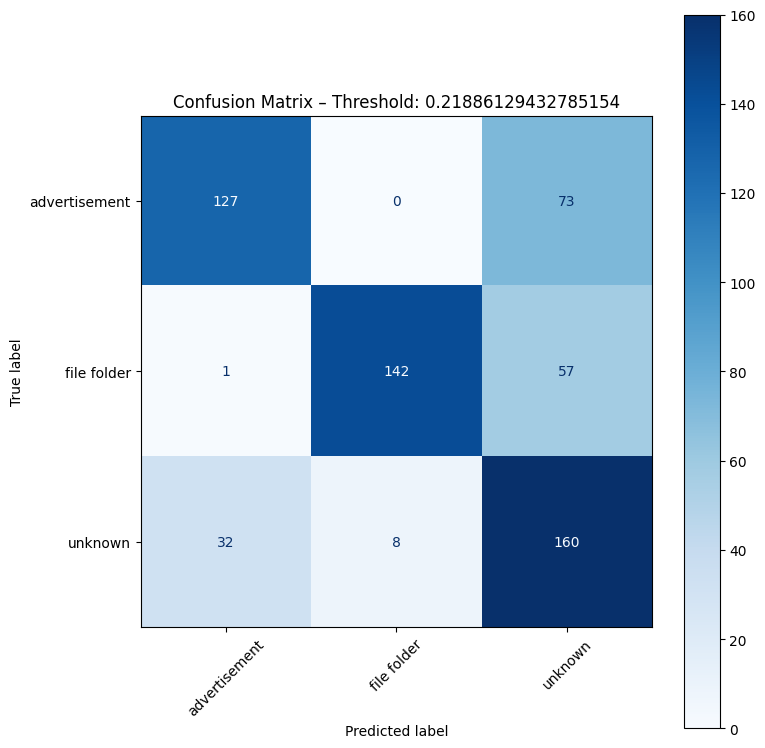

Klasse 'advertisement':
  -> Recall:    63.50%
  -> Precision: 79.38%
Klasse 'file folder':
  -> Recall:    71.00%
  -> Precision: 94.67%
Klasse 'unknown':
  -> Recall:    80.00%
  -> Precision: 55.17%
Gesamt-Accuracy: 71.50%


In [209]:
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, recall_score, precision_score, accuracy_score
import matplotlib.pyplot as plt

class_to_idx = {cls: i for i, cls in enumerate(ALLOWED_CLASSES)}
idx_to_class = dict(enumerate(NEW_ALLOWED_CLASSES))
unknown_id = -1

# Thresholds definieren
THRESHOLDS = [mean_dist * 0.95, mean_dist, mean_dist * 1.05]
MAX_IMAGES = 100000

folder_str = f"confusion_matrices/triplet/{len(ALLOWED_CLASSES)}_classes/{TEMPLATE_COUNT}_templates/{TEMPLATE_STRATEGY}_strategy"

# Optional: Verzeichnis zum Speichern der Plots
os.makedirs(folder_str, exist_ok=True)
output_file = os.path.join(folder_str, "metrics.txt")
with open(output_file, "w", encoding="utf-8") as f:
    for THRESHOLD in THRESHOLDS:
        print(f"\n================= Threshold: {THRESHOLD} =================")
        f.write(f"\n================= Threshold: {THRESHOLD} =================\n")

        all_preds, all_labels = [], []
        img_count = 0

        for batch in dataloader_with_new_classes:
            anc, _, _, anc_class, _ = batch

            for img, lbl_idx in zip(anc, anc_class):
                if img_count >= MAX_IMAGES:
                    break

                original_cls = idx_to_class[lbl_idx.item()]
                mapped_true = class_to_idx.get(original_cls, unknown_id)
                all_labels.append(mapped_true)

                img = img.unsqueeze(0).to(device)
                pred_cls = predict_class_of_img(net, img, known_class_datasets, threshold=THRESHOLD)
                mapped_pred = class_to_idx.get(pred_cls, unknown_id) if pred_cls != -1 else unknown_id
                all_preds.append(mapped_pred)

                img_count += 1
            if img_count >= MAX_IMAGES:
                break

        known_ids = list(class_to_idx.values())
        all_ids = known_ids + [unknown_id]
        label_names = [class_names[c] for c in ALLOWED_CLASSES] + ["unknown"]

        cm = confusion_matrix(all_labels, all_preds, labels=all_ids)

        fig, ax = plt.subplots(figsize=(8, 8))
        disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
        disp.plot(ax=ax, xticks_rotation=45, cmap="Blues")
        plt.title(f"Confusion Matrix – Threshold: {THRESHOLD}")
        plt.tight_layout()

        plt.savefig(f"{folder_str}/{int(THRESHOLD * 100):02d}.png")
        plt.show()

        recall_per_class = recall_score(all_labels, all_preds, labels=all_ids, average=None)
        precision_per_class = precision_score(all_labels, all_preds, labels=all_ids, average=None)

        for i, class_name in enumerate(label_names):
            recall_str = f"{recall_per_class[i]:.2%}"
            precision_str = f"{precision_per_class[i]:.2%}"
            print(f"Klasse '{class_name}':")
            print(f"  -> Recall:    {recall_str}")
            print(f"  -> Precision: {precision_str}")
            f.write(f"Klasse '{class_name}':\n")
            f.write(f"  -> Recall:    {recall_str}\n")
            f.write(f"  -> Precision: {precision_str}\n")

        overall_accuracy = accuracy_score(all_labels, all_preds)
        accuracy_str = f"{overall_accuracy:.2%}"
        print(f"Gesamt-Accuracy: {accuracy_str}")
        f.write(f"Gesamt-Accuracy: {accuracy_str}\n")



In [210]:
#Todo: strategy subordner und mit templatecount in der hierarchie tauschen
#todo: in ganzer python file functionizen und mit allen kombinationen laufen lassen